# M/M/1 queue sim

using event graph

## Base Code

In [1]:
# Libraries

import random
import math
import numpy as np
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class MMC_Sim:

    def __init__(self, replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1):
        '''
        intializing state variables
        '''
        # cofig variables
        self.entities = n_entity
        self.rep = replication
        self.next_event = 'start'
        
        # state variables
        self.clock = 0
        self.state = 0
        self.servers = servers

        # arrival variables
        self.tba = tba_fn
        self.arrival_rate = arrival_rate
        self.next_arrival = self.clock + self.tba(self.arrival_rate)

        # service variables
        self.service_time = service_t_fn
        self.service_rate = service_rate
        self.service_finish = float('inf')
        
        # event table
        self.df_cols = ['Replication', 'Event', 'Clock', 'Server', 'State', 'Next_Arrival',
                         'Service_finish']

        self.event_table = pd.DataFrame(columns=self.df_cols)
        self.df_val = []

    def reset(self):
        '''
        reset variable
        '''
        # state variables
        self.clock = 0
        self.state = 0
        self.servers = 1
        self.next_event = 'start'
    
        # arrival variables
        self.next_arrival = 0

        # service variables
        self.service_finish = float('inf')
    
    def event_calendar(self):

        if self.next_arrival < self.service_finish:
            self.clock = self.next_arrival
            self.next_arrival = float('inf')
            return 'arrival'
        else: 
            self.clock = self.service_finish
            self.service_finish = float('inf')
            return 'depart'

    
    def arrival(self):

        # increase state
        self.state += 1

        # update next arrival time 
        self.next_arrival = self.clock + self.tba(self.arrival_rate)

        # update service end time; server availble
        if self.servers > 0: 
            # append ts + last service end in queue
            self.service_finish = (self.clock + self.service_time(self.service_rate))
            self.servers -= 1 # decrease availble servers
        
    def depart(self):

        # decrease state
        self.state -= 1
        self.servers += 1 # update availble servers

        # update service end time; server availble
        if (self.servers > 0) and (self.state > 0): 
            # append ts + last service end in queue
            self.service_finish = (self.clock + self.service_time(self.service_rate))
            self.servers -= 1 # decrease availble servers


    def run_sim(self):
        '''
        function to process simulations
        '''
        df_val = []
        for rep in range(1, self.rep+1):
            entity_depart_sys = 0 # entities departed system
            self.reset() # reset state variables
            df_val.append([rep, self.next_event, self.clock, self.servers,
                     self.state,
                    self.next_arrival,
                    self.service_finish])
            while (entity_depart_sys <= self.entities):
                self.next_event = self.event_calendar()

                if self.next_event == 'arrival':
                    self.arrival()
                else:
                    self.depart()
                    entity_depart_sys += 1
                
                df_val.append([rep, self.next_event, self.clock, self.servers,
                     self.state,
                    self.next_arrival,
                    self.service_finish])
        self.event_table = pd.concat([self.event_table,
                                        pd.DataFrame(df_val, columns=self.df_cols)])
                


## running sim

In [3]:
# exponential time
def exp_time_diff(rate):
    return (-np.log(1-np.random.uniform())/rate).item()

In [4]:
replication = 100
n_entity = 10
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff
service_rate = 1.5
sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)

In [5]:
sim.run_sim()

C:\Users\prade\AppData\Local\Temp\ipykernel_7604\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,


In [6]:
df = sim.event_table.round(3)

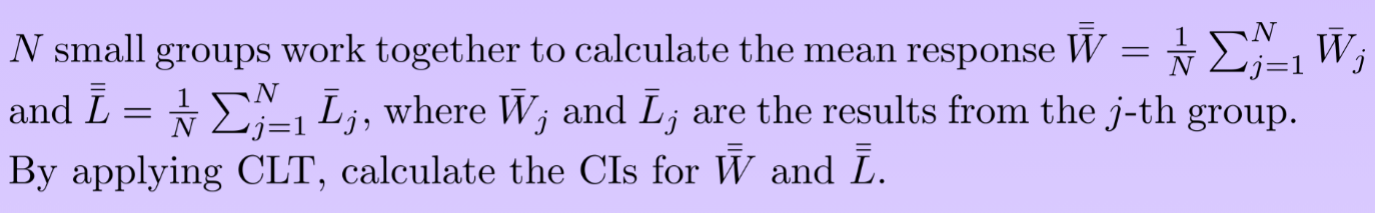

## Sample average - System waiting time

In [7]:
# first n_entities arrivals
arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
arrival_df.reset_index(inplace=True, drop=True)
arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

# first n_entities depart
depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
depart_df.reset_index(inplace=True, drop=True)
depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                   depart_df[['Event', 'Depart_Clock']]], axis=1)

C:\Users\prade\AppData\Local\Temp\ipykernel_7604\793491776.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_7604\793491776.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])


In [8]:
# W in system/ entity
W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
W_df_summ = W_df.groupby(['Replication']).agg({'W': 'mean'}).round(3).reset_index()

In [9]:
print(f'Sample average of system wait time')
lst = W_df_summ['W']
print(f'count: {len(lst)}')
print(f'max: {np.max(lst):.3f} | min: {np.min(lst):.3f}')
print(f'sample mean: {np.mean(lst):.3f} | sample standard dev.: {np.std(lst, ddof=1):.3f}')
z_critical = 1.96  # for 95% CI
margin_error_z = z_critical * (np.std(lst, ddof=1) / np.sqrt(len(lst)))
ci_lower_z = np.mean(lst) - margin_error_z
ci_upper_z = np.mean(lst) + margin_error_z
print(f"95% confidence interval: ({ci_lower_z:.3f}, {ci_upper_z:.3f})")


Sample average of system wait time
count: 100
max: 7.695 | min: 0.268
sample mean: 1.221 | sample standard dev.: 0.948
95% confidence interval: (1.035, 1.407)


## Sample average - System number of entities

In [10]:
# calculate dt
temp = df.groupby(['Replication']).apply(lambda x: x['Clock'].diff(-1)).to_list()
df['dt'] = -np.array(temp)
df['dt*S'] = df['dt']*df['State']

C:\Users\prade\AppData\Local\Temp\ipykernel_7604\1414028157.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = df.groupby(['Replication']).apply(lambda x: x['Clock'].diff(-1)).to_list()


In [11]:
L_df_summ = df.groupby(['Replication']).agg({'dt*S': 'sum', 'Clock': 'max'})
L_df_summ['L'] = L_df_summ['dt*S']/L_df_summ['Clock']

In [46]:
print(f'Sample average of expected enitities in system')
lst = L_df_summ['L']
print(f'count: {len(lst)}')
print(f'max: {np.max(lst):.3f} | min: {np.min(lst):.3f}')
print(f'sample mean: {np.mean(lst):.3f} | sample standard dev.: {np.std(lst, ddof=1):.3f}')
z_critical = 1.96  # for 95% CI
margin_error_z = z_critical * (np.std(lst, ddof=1) / np.sqrt(len(lst)))
ci_lower_z = np.mean(lst) - margin_error_z
ci_upper_z = np.mean(lst) + margin_error_z
print(f"95% confidence interval: ({ci_lower_z:.3f}, {ci_upper_z:.3f})")


Sample average of expected enitities in system
count: 100
max: 8.944 | min: 0.331
sample mean: 1.484 | sample standard dev.: 1.295
95% confidence interval: (1.230, 1.738)


## Bias in transient state

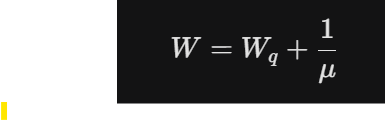

In [41]:
W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
W_df['Wq'] = W_df['W'] - 1/service_rate
W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()

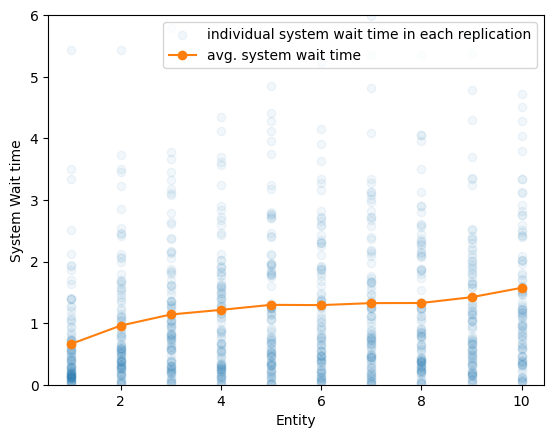

In [39]:
plt.scatter(W_df['entity'], W_df['W'], alpha=0.06, label='individual system wait time in each replication')
plt.plot(W_df_mean['entity'], W_df_mean['W'], label='avg. system wait time', marker='o', color='tab:orange')
plt.xlabel('Entity')
plt.ylabel('System Wait time')
plt.ylim(0, 6)
plt.legend()

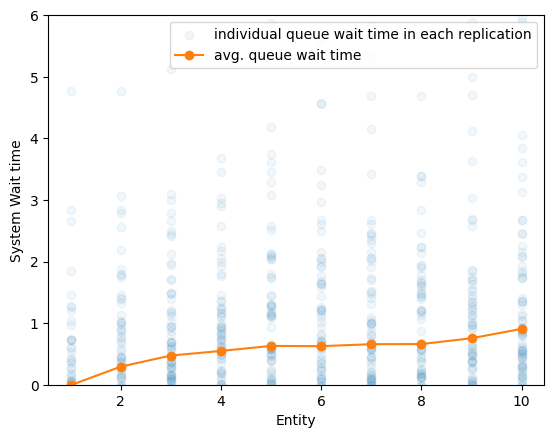

In [44]:
plt.scatter(W_df['entity'], W_df['Wq'], alpha=0.06, label='individual queue wait time in each replication')
plt.plot(W_df_mean['entity'], W_df_mean['Wq'], label='avg. queue wait time', marker='o', color='tab:orange')
plt.xlabel('Entity')
plt.ylabel('System Wait time')
plt.ylim(0, 6)
plt.legend()